## Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

REPORTS_DIR = Path.cwd() / "reports"

In [2]:
palette = [
    "#0072B2",
    "#6EC6F0",
    "#1A3A6B",
    "#77D4CC",
    "#009E73",
    "#44AA99",
    "#F2E55C",
    "#E69F00",
    "#556B00",
    "#D4669A",
    "#CC3311",
    "#DDDDDD",
    "#222222",
    "#882255"
]

cmap = mcolors.ListedColormap(palette, name="custom")

## Load Reports

In [3]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 11


## Convert to DataFrames

In [4]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [5]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [6]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Service functions

In [7]:
def df_section(df, section):
    subset = df[df.section == section]
    return subset.pivot(index="repo", columns="metric", values="value")

## Overview

In [8]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")

totals_pivot

section      Call Materialization          Callsites                         \
metric       Finalized Call Edges Accepted Callsites Not Accepted Callsites   
repo                                                                          
airbyte                   10757.0            10759.0                  295.0   
commons-lang               5376.0             5377.0                  357.0   
eslint                      833.0              834.0                   48.0   
guava                     34833.0            34868.0                 1789.0   
nodebb                     3433.0             3501.0                 2399.0   
npm-cli                    5573.0             5578.0                  292.0   
pydantic                   2512.0             2520.0                  448.0   
rollup                     8099.0             8141.0                 3729.0   
sympy                     57325.0            57348.0                11149.0   
vscode                   147745.0           148723.0                 6757.0   
webpack                    3838.0             3859.0                  157.0   

section                                         Not Accepted Callsites  \
metric       Observed Syntactic Callsites Insufficient Static Evidence   
repo                                                                     
airbyte                           11054.0                        205.0   
commons-lang                       5734.0                        112.0   
eslint                              882.0                         41.0   
guava                             36657.0                        413.0   
nodebb                             5900.0                       1226.0   
npm-cli                            5870.0                        270.0   
pydantic                           2968.0                        441.0   
rollup                            11870.0                       3678.0   
sympy                             68497.0                      11136.0   
vscode                           155480.0                       5609.0   
webpack                            4016.0                        108.0   

section                                                                \
metric       Outside Static Contract Structural Mismatch Unclassified   
repo                                                                    
airbyte                          2.0                88.0          0.0   
commons-lang                    63.0               182.0          0.0   
eslint                           7.0                 0.0          0.0   
guava                          120.0              1256.0          0.0   
nodebb                        1173.0                 0.0          0.0   
npm-cli                         22.0                 0.0          0.0   
pydantic                         7.0                 0.0          0.0   
rollup                          45.0                 6.0          0.0   
sympy                            5.0                 8.0          0.0   
vscode                        1043.0               105.0          0.0   
webpack                         14.0                35.0          0.0   

section      Structure           ...                    Timing  \
metric           Edges    Files  ... Compute Build Fingerprint   
repo                             ...                             
airbyte        35207.0   3288.0  ...                  0.781418   
commons-lang   16979.0    534.0  ...                  0.222655   
eslint          3251.0   1499.0  ...                  0.234322   
guava         102049.0   3245.0  ...                  0.285788   
nodebb          8683.0    883.0  ...                  0.254723   
npm-cli        15318.0   1545.0  ...                  0.599496   
pydantic       16531.0    407.0  ...                  0.664593   
rollup         20278.0  12474.0  ...                  0.379465   
sympy         109958.0   1590.0  ...                  0.333332   
vscode        319386.0   6765.0  ...     

In [9]:
timing_total_df = df_section(totals_df, "Timing").copy()
timing_total_df["Build Wall Time"] = (
    timing_total_df["Build Wall Time"]
    - timing_total_df["Diagnostic Classification"])

timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)

In [10]:
timing_total_df = df_section(totals_df, "Timing")[["Build Wall Time"]]
timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)
timing_total_df = timing_total_df.join(df_section(totals_df, "Structure")[["Nodes", "Edges"]])
timing_total_df["Nodes + Edges"] = timing_total_df["Nodes"] + timing_total_df["Edges"]
timing_total_df["Time per 1K Nodes"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes"] / 1000)
timing_total_df["Time per 1K Edges"] = timing_total_df["Build Wall Time"] / (timing_total_df["Edges"] / 1000)
timing_total_df["Time per 1K (Nodes + Edges)"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes + Edges"] / 1000)

timing_sum = timing_total_df.sum(axis=0, numeric_only=True)
timing_mean = timing_total_df.mean(numeric_only=True)
timing_median = timing_total_df.median(numeric_only=True)

timing_sum.name = "Total"
timing_mean.name = "Mean"
timing_median.name = "Median"

timing_overview_df = pd.concat([timing_total_df, timing_mean.to_frame().T, timing_median.to_frame().T, timing_sum.to_frame().T]).round(2)
timing_overview_df

metric,Build Wall Time,Nodes,Edges,Nodes + Edges,Time per 1K Nodes,Time per 1K Edges,Time per 1K (Nodes + Edges)
nodebb,15.49,3349.00,8683.00,12032.0,4.63,1.78,1.29
commons-lang,18.62,11566.00,16979.00,28545.0,1.61,1.10,0.65
eslint,19.34,3115.00,3251.00,6366.0,6.21,5.95,3.04
pydantic,19.50,13301.00,16531.00,29832.0,1.47,1.18,0.65
npm-cli,30.39,9752.00,15318.00,25070.0,3.12,1.98,1.21
webpack,46.86,15815.00,15961.00,31776.0,2.96,2.94,1.47
airbyte,60.91,25275.00,35207.00,60482.0,2.41,1.73,1.01
rollup,63.24,19675.00,20278.00,39953.0,3.21,3.12,1.58
guava,147.84,64135.00,102049.00,166184.0,2.31,1.45,0.89
sympy,354.69,40980.00,109958.00,150938.0,8.66,3.23,2.35


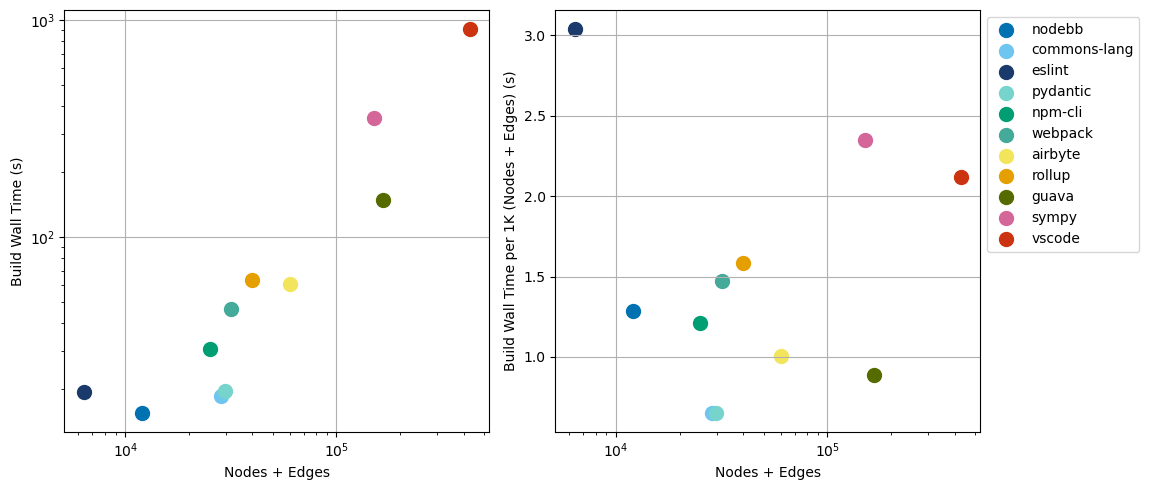

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for i, repo in enumerate(timing_total_df.index):
    color = palette[i % len(palette)]
    x = timing_total_df.loc[repo, "Nodes + Edges"]
    y1 = timing_total_df.loc[repo, "Build Wall Time"]
    y2 = timing_total_df.loc[repo, "Time per 1K (Nodes + Edges)"]

    axes[0].scatter(x, y1, color=color, s=100, label=repo)
    axes[1].scatter(x, y2, color=color, s=100)

axes[0].set_xlabel("Nodes + Edges")
axes[0].set_ylabel("Build Wall Time (s)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].set_xlabel("Nodes + Edges")
axes[1].set_ylabel("Build Wall Time per 1K (Nodes + Edges) (s)")
axes[1].set_xscale("log")
axes[1].grid(True)

fig.legend(loc="upper left", bbox_to_anchor=(0.985, 0.97))
plt.tight_layout()
plt.show()

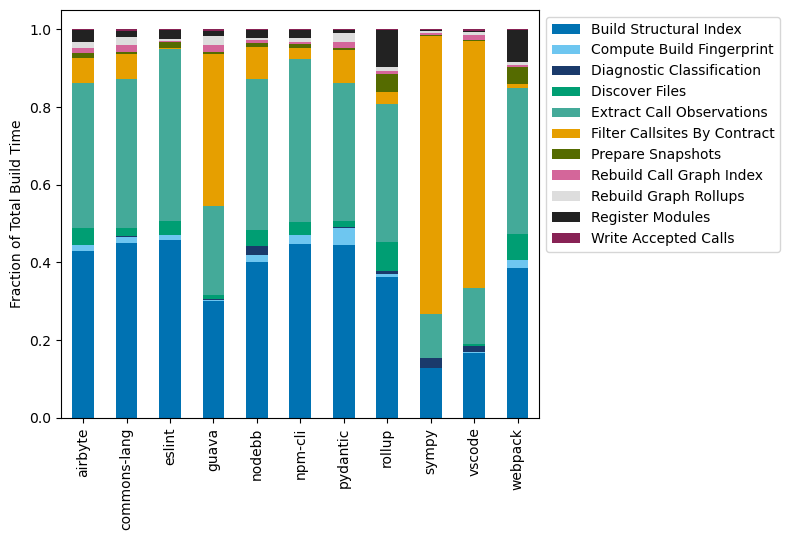

In [11]:
timing_phases_df = df_section(totals_df, "Timing").drop(columns=["Build Total Time", "Build Wall Time", "Diagnostic Classification (Phase I)", "Diagnostic Classification (Phase II)"], errors="ignore")
timing_phases_df = timing_phases_df.div(timing_phases_df.sum(axis=1), axis=0)

timing_phases_df.plot( kind="bar", stacked=True, colormap=cmap, figsize=(8, 5.5))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of Total Build Time")
plt.tight_layout()
plt.show()

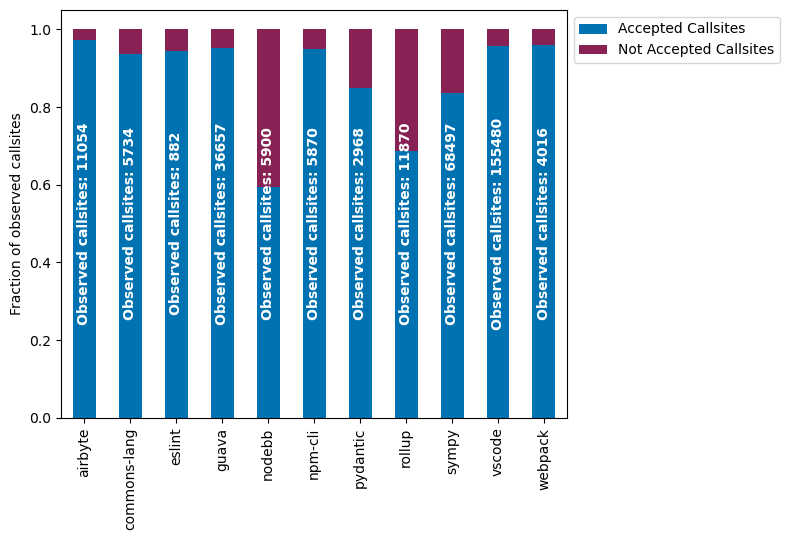

In [12]:
observed_callsites = df_section(totals_df, "Callsites")["Observed Syntactic Callsites"]

callsites_df = df_section(totals_df, "Callsites").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5.5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(observed_callsites.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()

In [13]:
callsites_df.sort_values("Accepted Callsites", ascending=True)

metric,Accepted Callsites,Not Accepted Callsites
repo,,
nodebb,0.593390,0.406610
rollup,0.685847,0.314153
sympy,0.837234,0.162766
pydantic,0.849057,0.150943
commons-lang,0.937740,0.062260
eslint,0.945578,0.054422
npm-cli,0.950256,0.049744
guava,0.951196,0.048804
vscode,0.956541,0.043459


## Language breakdown

In [14]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section                 Call Materialization          Callsites  \
metric                  Finalized Call Edges Accepted Callsites   
repo         language                                             
airbyte      java                       1556               1556   
             javascript                   74                 74   
             python                     9125               9127   
             typescript                    2                  2   
commons-lang java                       5376               5377   
eslint       javascript                  833                834   
             typescript                    0                  0   
guava        java                      34833              34868   
             javascript                    0                  0   
nodebb       javascript                 3433               3501   
             typescript                    0                  0   
npm-cli      javascript                 4210               4215   
             python                     1363               1363   
pydantic     javascript                    8                  8   
             python                     2504               2512   
rollup       javascript                 6002               6002   
             typescript                 2097               2139   
sympy        python                    57325              57348   
vscode       java                          0                  0   
             javascript                  154                154   
             python                        0                  0   
             typescript               147591             148569   
webpack      javascript                 3826               3847   
             typescript                   12                 12   

section                                                                      \
metric                  Not Accepted Callsites Observed Syntactic Callsites   
repo         language                                                         
airbyte      java                           63                         1619   
             javascript                      0                           74   
             python                        232                         9359   
             typescript                      0                            2   
commons-lang java                          357                         5734   
eslint       javascript                     48                          882   
             typescript                      0                            0   
guava        java                         1789                        36657   
             javascript                      0                            0   
nodebb       javascript                   2399                         5900   
             typescript                      0                            0   
npm-cli      javascript                    268                         4483   
             python                         24                         1387   
pydantic     javascript                      0                            8   
             python                        448                         2960   
rollup       javascript                   3509                         9511   
             typescript                    220                         2359   
sympy        python                      11149                        68497   
vscode       java                            0                            0   
             javascript                      0                          154   
             python                          0                            0   
             typescript                   6757                       155326   
webpack      javascript                    157                         4004   
             typescript                      0                           12   

section                       Not Accepted Callsites    

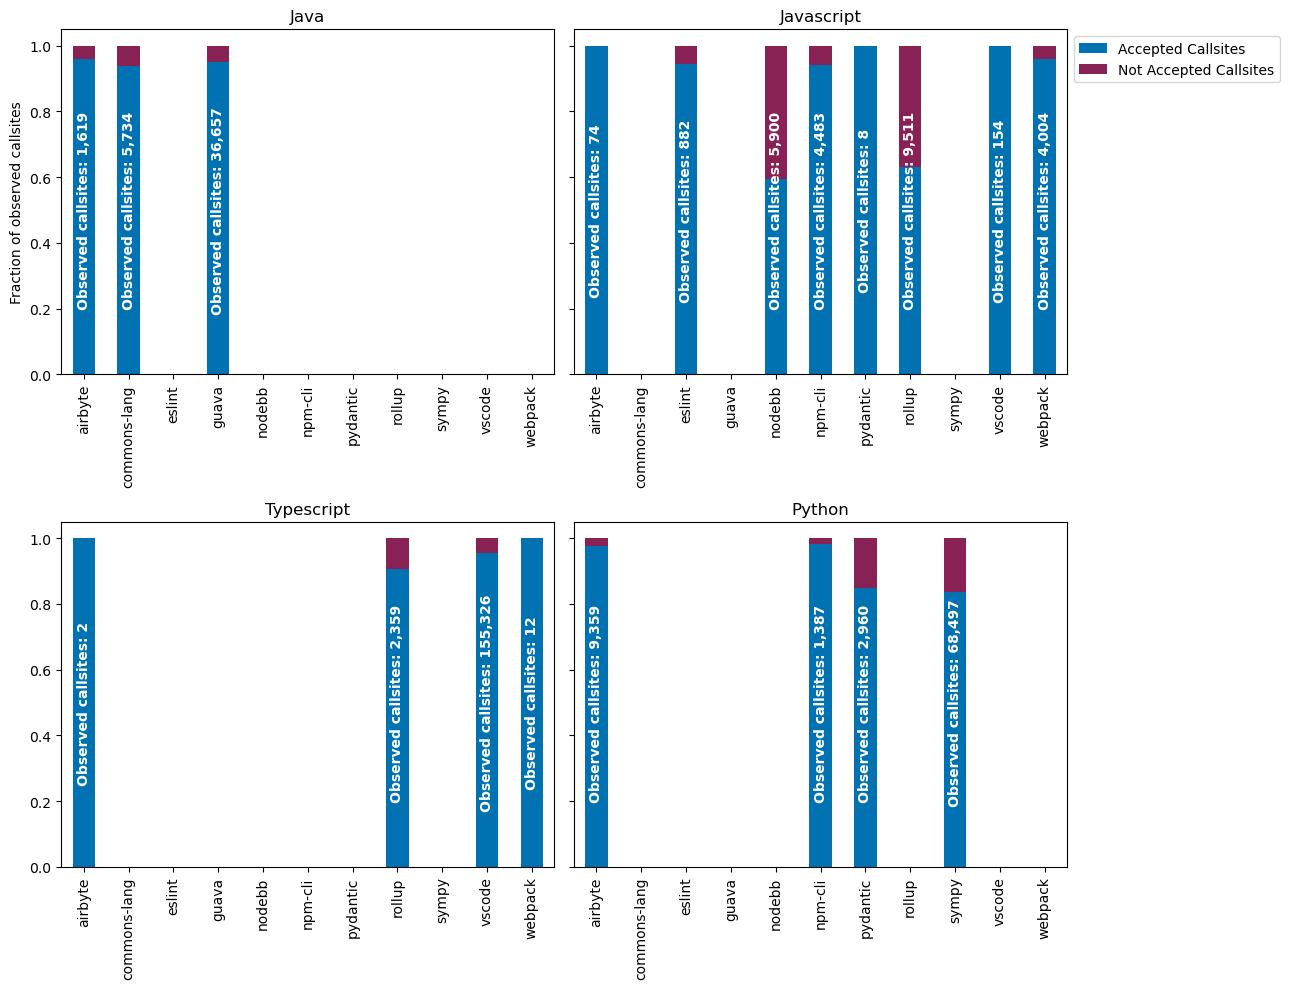

In [15]:
observed_callsites = languages_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

all_repos = callsites_df.index.get_level_values("repo").unique()

java_df = callsites_df.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_df = callsites_df.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_df = callsites_df.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_df = callsites_df.xs("python", level="language").reindex(all_repos, fill_value=0)

java_callsites = observed_callsites.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_callsites = observed_callsites.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_callsites = observed_callsites.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_callsites = observed_callsites.xs("python", level="language").reindex(all_repos, fill_value=0)

fig, axes = plt.subplots(2,2, figsize=(13,10), sharey=True)

java_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,0], legend=False)
javascript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,1])
typescript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,0], legend=False)
python_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,1], legend=False)

for i, (repo, value) in enumerate(java_callsites.items()):
    axes[0,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(javascript_callsites.items()):
    axes[0,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(typescript_callsites.items()):
    axes[1,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(python_callsites.items()):
    axes[1,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

axes[0,0].set_title("Java")
axes[0,1].set_title("Javascript")
axes[1,0].set_title("Typescript")
axes[1,1].set_title("Python")

for ax in axes.flat: ax.set_xlabel("")
axes[0,0].set_ylabel("Fraction of observed callsites")
axes[0,1].legend(bbox_to_anchor=(1,1), loc="upper left")

plt.tight_layout()
plt.show()

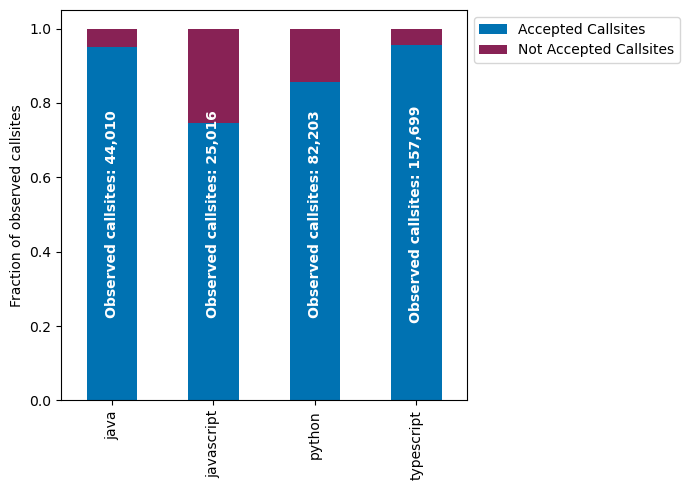

In [16]:
callsites_raw_df = languages_pivot.groupby(level="language").sum()
callsites_counts = callsites_raw_df.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.groupby(level="language").sum()
callsites_df = callsites_df.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (lang, value) in enumerate(callsites_counts.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.legend(bbox_to_anchor=(1,1), loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Fraction of observed callsites")

plt.tight_layout()
plt.show()

In [17]:
callsites_raw_df

section    Call Materialization          Callsites                         \
metric     Finalized Call Edges Accepted Callsites Not Accepted Callsites   
language                                                                    
java                      41765              41801                   2209   
javascript                18540              18635                   6381   
python                    70317              70350                  11853   
typescript               149702             150722                   6977   

section                                       Not Accepted Callsites  \
metric     Observed Syntactic Callsites Insufficient Static Evidence   
language                                                               
java                              44010                          551   
javascript                        25016                         5127   
python                            82203                        11779   
typescript                       157699                         5782   

section                                                             Structure  \
metric     Outside Static Contract Structural Mismatch Unclassified     Edges   
language                                                                        
java                           185                1473            0    124413   
javascript                    1219                  35            0     54861   
python                          13                  61            0    158912   
typescript                    1084                 111            0    325415   

section                    
metric      Files   Nodes  
language                   
java         4251   79844  
javascript  24728   48023  
python       4820   76701  
typescript   7134  110523

In [18]:
callsites_df.sort_values("Accepted Callsites", ascending=True)

metric,Accepted Callsites,Not Accepted Callsites
language,,
javascript,0.744923,0.255077
python,0.855808,0.144192
java,0.949807,0.050193
typescript,0.955757,0.044243


## Scope breakdown

In [19]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")
scopes_pivot

section                Call Materialization          Callsites  \
metric                 Finalized Call Edges Accepted Callsites   
repo         scope                                               
airbyte      Non-Tests                10152              10154   
             Tests                      605                605   
commons-lang Non-Tests                 3325               3326   
             Tests                     2051               2051   
eslint       Non-Tests                  815                816   
             Tests                       18                 18   
guava        Non-Tests                22928              22963   
             Tests                    11905              11905   
nodebb       Non-Tests                 3409               3475   
             Tests                       24                 26   
npm-cli      Non-Tests                 5376               5381   
             Tests                      197                197   
pydantic     Non-Tests                 1417               1417   
             Tests                     1095               1103   
rollup       Non-Tests                 2135               2177   
             Tests                     5964               5964   
sympy        Non-Tests                23668              23690   
             Tests                    33657              33658   
vscode       Non-Tests               125259             126224   
             Tests                    22486              22499   
webpack      Non-Tests                 3423               3444   
             Tests                      415                415   

section                                                                     \
metric                 Not Accepted Callsites Observed Syntactic Callsites   
repo         scope                                                           
airbyte      Non-Tests                    286                        10440   
             Tests                          9                          614   
commons-lang Non-Tests                     78                         3404   
             Tests                        279                         2330   
eslint       Non-Tests                     44                          860   
             Tests                          4                           22   
guava        Non-Tests                    611                        23574   
             Tests                       1178                        13083   
nodebb       Non-Tests                   2396                         5871   
             Tests                          3                           29   
npm-cli      Non-Tests                    292                         5673   
             Tests                          0                          197   
pydantic     Non-Tests                    152                         1569   
             Tests                        296                         1399   
rollup       Non-Tests                    227                         2404   
             Tests                       3502                         9466   
sympy        Non-Tests                   2792                        26482   
             Tests                       8357                        42015   
vscode       Non-Tests                   6553                       132777   
             Tests                        204                        22703   
webpack      Non-Tests                    150                         3594   
             Tests                          7                          422   

section                      Not Accepted Callsites                          \
metric                 Insufficient Static Evidence Outside Static Contract   
repo         scope                                                            
airbyte      Non-Tests                          200                       2   
             Tests                                5                       0   
com

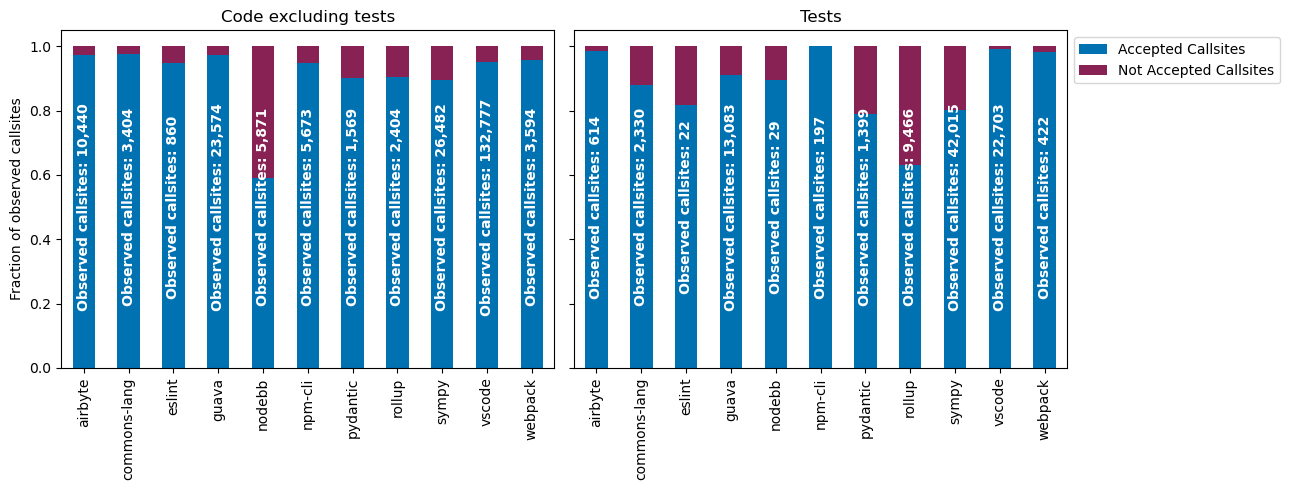

In [20]:
callsites_counts = scopes_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]
counts_non_tests = callsites_counts.xs("Non-Tests", level="scope")
counts_tests = callsites_counts.xs("Tests", level="scope")

callsites_df = scopes_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

non_test_df = callsites_df.xs("Non-Tests", level="scope")
tests_df = callsites_df.xs("Tests", level="scope")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

non_test_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0],legend=False)
tests_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1])

for i, (repo, value) in enumerate(counts_non_tests.items()):
    axes[0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(counts_tests.items()):
    axes[1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    
axes[0].set_title("Code excluding tests")
axes[1].set_title("Tests")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of observed callsites")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
non_test_df.sort_values("Accepted Callsites", ascending=True)

metric,Accepted Callsites,Not Accepted Callsites
repo,,
nodebb,0.591892,0.408108
sympy,0.894570,0.105430
pydantic,0.903123,0.096877
rollup,0.905574,0.094426
npm-cli,0.948528,0.051472
eslint,0.948837,0.051163
vscode,0.950647,0.049353
webpack,0.958264,0.041736
airbyte,0.972605,0.027395


In [22]:
tests_df.sort_values("Accepted Callsites", ascending=True)

metric,Accepted Callsites,Not Accepted Callsites
repo,,
rollup,0.630044,0.369956
pydantic,0.788420,0.211580
sympy,0.801095,0.198905
eslint,0.818182,0.181818
commons-lang,0.880258,0.119742
nodebb,0.896552,0.103448
guava,0.909959,0.090041
webpack,0.983412,0.016588
airbyte,0.985342,0.014658


## Diagnostics
Best-effort classification of not-accepted callsites

In [23]:
df_section(totals_df, "Not Accepted Callsites")

metric,Insufficient Static Evidence,Outside Static Contract,Structural Mismatch,Unclassified
repo,,,,
airbyte,205.0,2.0,88.0,0.0
commons-lang,112.0,63.0,182.0,0.0
eslint,41.0,7.0,0.0,0.0
guava,413.0,120.0,1256.0,0.0
nodebb,1226.0,1173.0,0.0,0.0
npm-cli,270.0,22.0,0.0,0.0
pydantic,441.0,7.0,0.0,0.0
rollup,3678.0,45.0,6.0,0.0
sympy,11136.0,5.0,8.0,0.0


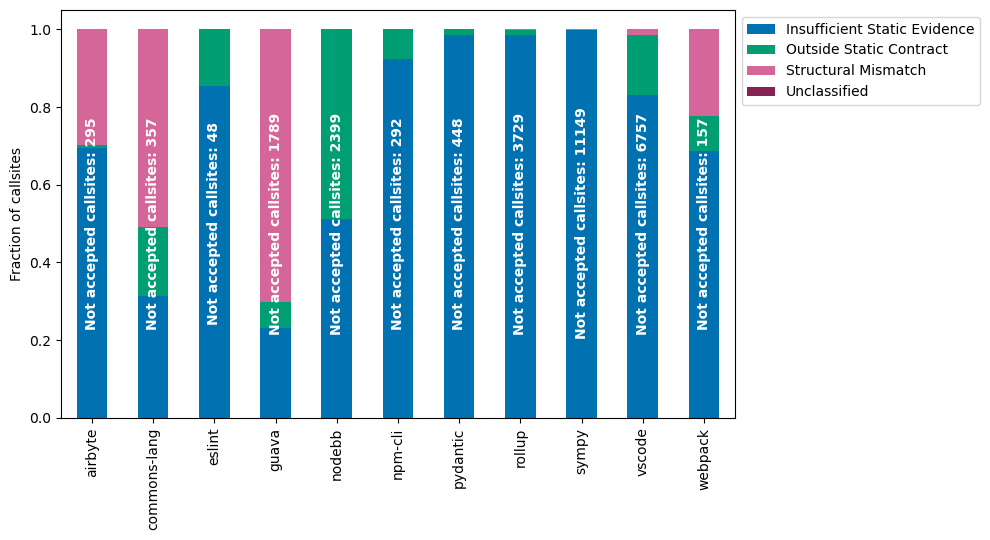

In [24]:
pre_persist = df_section(totals_df, "Callsites")["Not Accepted Callsites"]

pre_persist_df = df_section(totals_df, "Not Accepted Callsites")
pre_persist_df = pre_persist_df.div(pre_persist_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10,5.5))

pre_persist_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(pre_persist.items()):
    ax.text(i, 0.5, f"Not accepted callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of callsites")
plt.tight_layout()
plt.show()